# Probe Guidance: Exploring the Cross Entropy Method

The cross entropy method (CEM) is what enables the VJEPA2 AC predictor architecture to perform planning. Thus making enabling it to become a world model (imagining actions and their consequences on the environment) that can be deployed in a real world task (robot manipulation, probe guidance, etc.)

We want to know how well this world modeling approach works from two perspectives: time and error. We need to know how long it takes the world model to do a single inference step, and how much error is in it's predictions. Besides raw performance of the predictor (we could even assume a perfect predictor), There are several parameters that have control over the inference time and error of the world model, namely the number of CEM steps, rollout steps, and samples.

To get a good idea of which sets of parameters work best, the `cem_hyperparameter_grid_search.py` file enables us to find good configurations over a validaton set. The best set of parameters should result in short inference times and low error between predicted actions and ground truth actions, and ideally also work well on an unseen test set.

## CEM Hyperparameter Grid Search Results

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Set notebook display preferences
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

### Basic Tables

In [3]:
df_results = pd.read_csv("cem_hyperparameter_search_0.csv")

In [4]:
df_results.sort_values(by="mean_rep_l1_error", ascending=True).head(5)

,rollout,samples,topk,cem_steps,mean_inference_latency_ms,std_inference_latency_ms,mean_rep_l1_error,std_rep_l1_error,mean_pose_error_m,std_pose_error_m
3,1,20,10,10,851.057908,2.381045,0.441009,0.028549,0.050691,0.017112
2,1,20,10,5,479.620147,1.082536,0.441157,0.028543,0.045859,0.016599
1,1,10,10,10,497.094441,1.314597,0.441792,0.028995,0.025583,0.014252
0,1,10,10,5,399.861768,1577.504760,0.441869,0.028959,0.024815,0.014232
7,2,20,10,10,2490.199976,2.602456,0.444298,0.024644,0.067264,0.021066


In [5]:
df_results.sort_values(by="mean_pose_error_m", ascending=True).head(5)

,rollout,samples,topk,cem_steps,mean_inference_latency_ms,std_inference_latency_ms,mean_rep_l1_error,std_rep_l1_error,mean_pose_error_m,std_pose_error_m
0,1,10,10,5,399.861768,1577.504760,0.441869,0.028959,0.024815,0.014232
1,1,10,10,10,497.094441,1.314597,0.441792,0.028995,0.025583,0.014252
4,2,10,10,5,836.343145,1777.043236,0.445683,0.025327,0.032580,0.016296
5,2,10,10,10,1334.790806,2.119875,0.445735,0.025432,0.033240,0.017274
9,3,10,10,10,2659.286907,1.992742,0.449727,0.023765,0.038673,0.017088


In [6]:
rollout_impact = df_results.groupby("rollout")[[
    "mean_rep_l1_error", 
    "mean_pose_error_m", 
    "mean_inference_latency_ms"
]].mean()

print("--- Impact of Rollout Horizon ---")
print(rollout_impact)

--- Impact of Rollout Horizon ---
         mean_rep_l1_error  mean_pose_error_m  mean_inference_latency_ms
rollout                                                                 
1                 0.441457           0.036737                 556.908566
2                 0.445044           0.048196                1491.166596
3                 0.448715           0.058418                2947.082016


### Pivot Tables

In [7]:
pivot_rep_error = pd.pivot_table(
    df_results,
    values="mean_rep_l1_error",
    index=["samples", "topk", "cem_steps"],
    columns=["rollout"],
    aggfunc="mean",
)
print("=== MEAN REP L1 ERROR BY CONFIG ===")
display(pivot_rep_error.round(4))

=== MEAN REP L1 ERROR BY CONFIG ===


rollout                      1       2       3
samples topk cem_steps                        
10      10   5          0.4419  0.4457  0.4496
             10         0.4418  0.4457  0.4497
20      10   5          0.4412  0.4445  0.4479
             10         0.4410  0.4443  0.4477

In [8]:
pivot_latency = pd.pivot_table(
    df_results,
    values="mean_inference_latency_ms",
    index=["samples", "topk", "cem_steps"],
    columns=["rollout"],
    aggfunc="mean",
)
print("\n=== MEAN INFERENCE LATENCY (MS) BY CONFIG ===")
display(pivot_latency.round(1))


=== MEAN INFERENCE LATENCY (MS) BY CONFIG ===


rollout                     1       2       3
samples topk cem_steps                       
10      10   5          399.9   836.3  1394.2
             10         497.1  1334.8  2659.3
20      10   5          479.6  1303.3  2621.1
             10         851.1  2490.2  5113.7

### Pareto Frontier

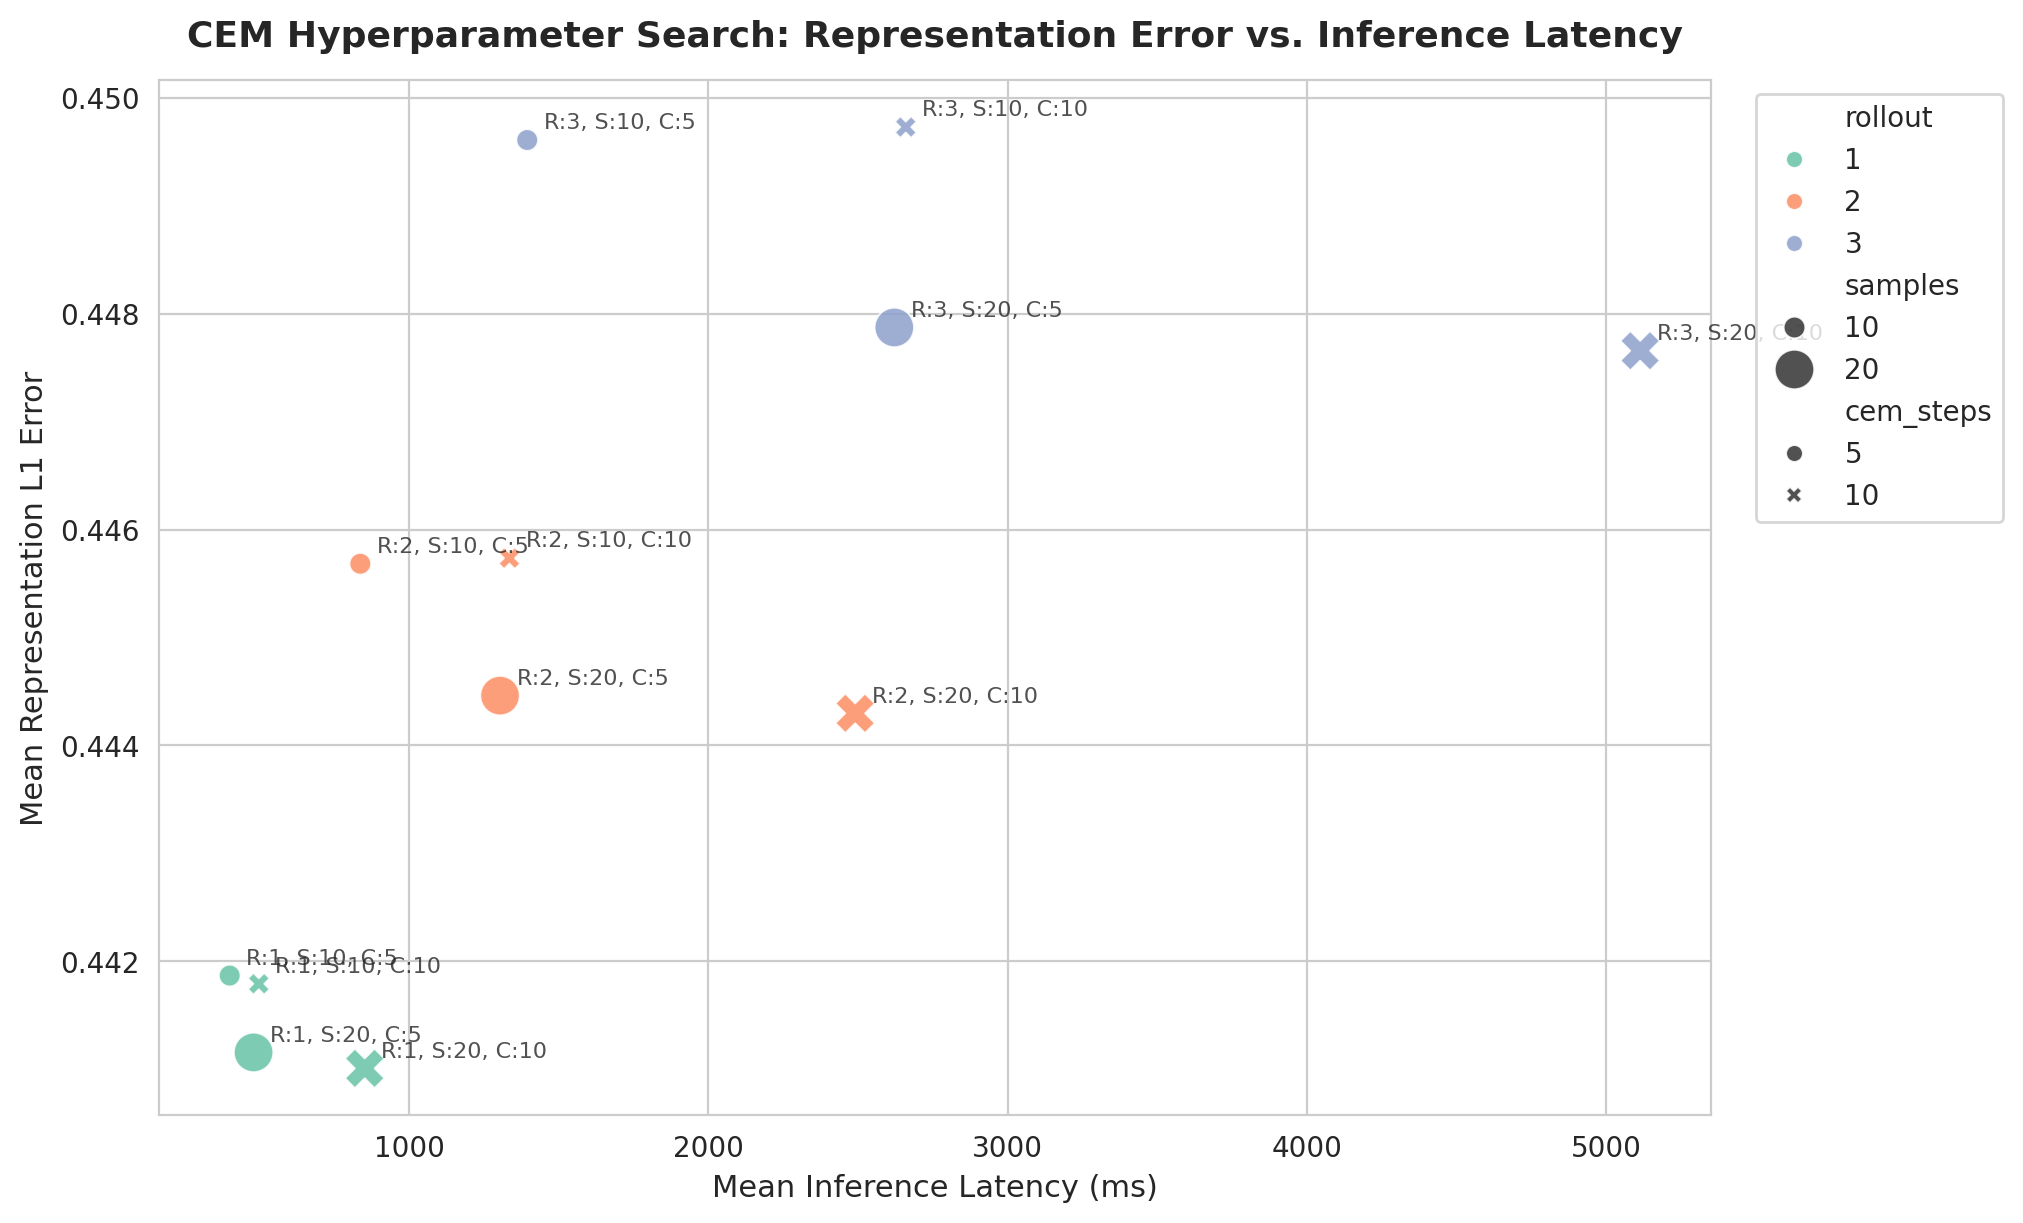

In [9]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

    sns.scatterplot(
        data=df_results,
        x="mean_inference_latency_ms",
        y="mean_rep_l1_error",
        hue="rollout",
        style="cem_steps",
        size="samples",
        sizes=(60, 200),
        palette="Set2",
        alpha=0.85,
        ax=ax,
    )

    # Annotate points with parameter tags
    for _, row in df_results.iterrows():
        label = f"R:{int(row['rollout'])}, S:{int(row['samples'])}, C:{int(row['cem_steps'])}"
        ax.annotate(
            label,
            (row["mean_inference_latency_ms"], row["mean_rep_l1_error"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8,
            alpha=0.8,
        )

    ax.set_title(
        "CEM Hyperparameter Search: Representation Error vs. Inference Latency",
        fontsize=13,
        pad=12,
        weight="bold",
    )
    ax.set_xlabel("Mean Inference Latency (ms)", fontsize=11)
    ax.set_ylabel("Mean Representation L1 Error", fontsize=11)

    sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))

    plt.show()

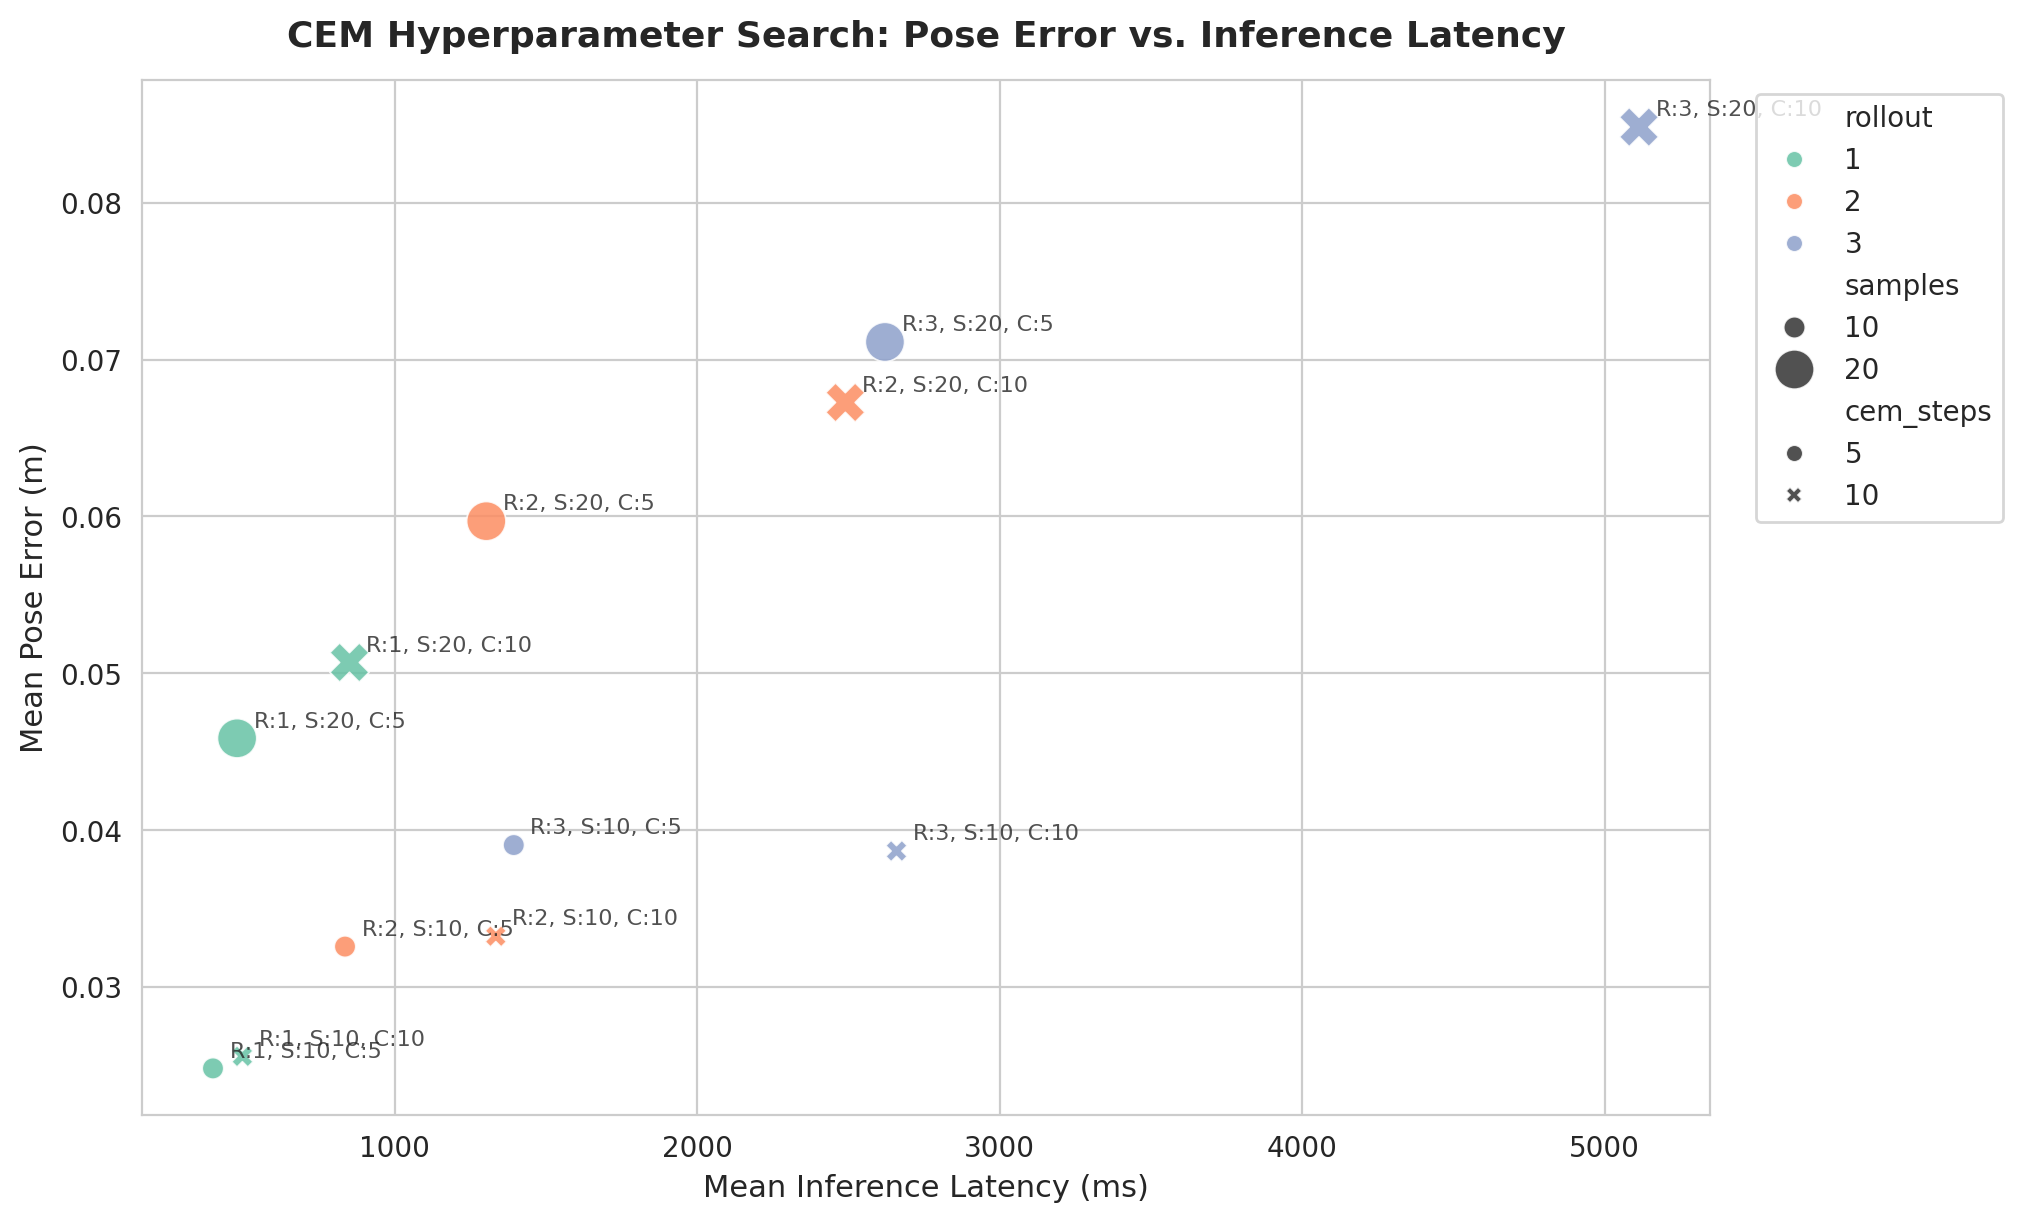

In [10]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")

    sns.scatterplot(
        data=df_results,
        x="mean_inference_latency_ms",
        y="mean_pose_error_m",
        hue="rollout",
        style="cem_steps",
        size="samples",
        sizes=(60, 200),
        palette="Set2",
        alpha=0.85,
        ax=ax,
    )

    # Annotate points with parameter tags
    for _, row in df_results.iterrows():
        label = f"R:{int(row['rollout'])}, S:{int(row['samples'])}, C:{int(row['cem_steps'])}"
        ax.annotate(
            label,
            (row["mean_inference_latency_ms"], row["mean_pose_error_m"]),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=8,
            alpha=0.8,
        )

    ax.set_title(
        "CEM Hyperparameter Search: Pose Error vs. Inference Latency",
        fontsize=13,
        pad=12,
        weight="bold",
    )
    ax.set_xlabel("Mean Inference Latency (ms)", fontsize=11)
    ax.set_ylabel("Mean Pose Error (m)", fontsize=11)

    sns.move_legend(ax, "upper left", bbox_to_anchor=(1.02, 1))

    plt.show()